# Curación de datos multi-fuente → corpus para la Práctica 7

**Qué hace este notebook.** Toma los datasets crudos repartidos de la Práctica 6
(varias redes) y produce un **corpus limpio y unificado** para el modelo de
análisis de sentimientos de la Práctica 7. El énfasis está en **auditar la
calidad ANTES de concatenar**: perfilamos cada fuente, decidimos qué entra y qué
se descarta con evidencia, aplicamos reglas de curación uniformes y recién ahí
consolidamos.

**Entradas** (solo lectura, en `practica_06/data/`):
- `dataset.jsonl` — consolidado YouTube + X (375k registros).
- `bluesky_curado.csv` — corrida grande de Bluesky (compañero, ~26k).
- `tiktok_curado.csv` — corrida de TikTok (compañero).
- `tumblr.csv` — corrida de Tumblr (fuente nueva).
- `twitch.csv` — corrida de Twitch (fuente nueva; se evalúa y **se descarta**).

**Salidas** (en `practica_07/data/`):
- `corpus_completo.csv` / `.jsonl` — todo lo curado (todas las redes válidas).
- `corpus_dirigida.csv` / `.jsonl` — el núcleo denso (recolección dirigida o
  con término del léxico), auditable a mano.
- `reporte_curacion.md` — resumen antes/después de la curación.

> **Nota de reproducibilidad.** No se modifica nada de `practica_06/`; es la
> fuente inmutable. Este notebook se puede re-ejecutar tal cual cuando lleguen
> datasets aumentados.

In [1]:
import json, re, sys, unicodedata
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
})
# Paleta apta para daltonismo (misma que los AED de la P6).
AZUL, NARANJA, VERDE, ROJO = "#4E79A7", "#F28E2B", "#59A14F", "#E15759"
pd.set_option("display.max_colwidth", 90)

# --- Localizar el repo sin depender del cwd (funciona desde P6, P7 o la raíz) ---
def encontrar_raiz(marcador="practica_06"):
    p = Path.cwd().resolve()
    for cand in (p, *p.parents):
        if (cand / marcador).is_dir():
            return cand
    raise RuntimeError(f"No encuentro '{marcador}' subiendo desde {Path.cwd()}")

RAIZ = encontrar_raiz()
P6, P7 = RAIZ / "practica_06", RAIZ / "practica_07"
DATA_IN, DATA_OUT = P6 / "data", P7 / "data"
DATA_OUT.mkdir(parents=True, exist_ok=True)

# El léxico xenófobo es la FUENTE ÚNICA de verdad: el mismo código que marca en
# el extractor y en los AED. Re-marcamos aquí para que las 3 redes queden con
# criterio idéntico (dirigida/eje) y para corregir falsos positivos por substring.
sys.path.insert(0, str(P6 / "src"))
from extractor_mundial.lexico import cargar as cargar_lexico

LEX = cargar_lexico(P6 / "config" / "lexico.txt")
N_EJES = len({e.eje for e in LEX.entradas})
print(f"raíz del repo: {RAIZ}")
print(f"léxico activo: {len(LEX.entradas)} términos en {N_EJES} ejes")

# Columnas del CONTRATO (orden canónico; las 3 redes comparten esquema).
COLS = ["id", "red", "estrategia", "criterio_busqueda", "texto", "idioma",
        "autor", "fecha_publicacion", "url", "metricas", "fecha_extraccion"]

raíz del repo: /home/felipep/Documentos/universidad/universidad 8vo/computacion_paralela/proyecto_final_ciclo
léxico activo: 104 términos en 6 ejes


## 1. Carga de fuentes (crudo, sin tocar)

Cargamos cada fuente por separado y **normalizamos solo el contenedor** (mismo
esquema del contrato, `metricas` como dict en memoria). Nada de limpieza todavía:
esta es la materia prima para la "foto antes".

In [3]:
def a_dict(m):
    """metricas → dict. En el jsonl ya es dict; en los CSV viene como JSON string."""
    if isinstance(m, dict):
        return m
    if m is None or (isinstance(m, float)) or (isinstance(m, str) and not m.strip()):
        return {}
    try:
        d = json.loads(m)
        return d if isinstance(d, dict) else {}
    except (ValueError, TypeError):
        return {}

def _normalizar_df(df):
    """Garantiza todas las columnas del contrato y metricas como dict."""
    for c in COLS:
        if c not in df.columns:
            df[c] = None
    df = df[COLS].copy()
    df["metricas"] = df["metricas"].apply(a_dict)
    # NaN de pandas → None limpio en los campos de texto
    for c in ["idioma", "autor", "fecha_publicacion", "url", "texto", "criterio_busqueda"]:
        df[c] = df[c].where(df[c].notna(), None)
    return df

# YouTube + X salen del jsonl consolidado; el resto, de sus CSV.
regs = [json.loads(l) for l in (DATA_IN / "dataset.jsonl").read_text(encoding="utf-8").splitlines() if l.strip()]
df_jsonl = pd.DataFrame(regs)
df_youtube = _normalizar_df(df_jsonl[df_jsonl["red"] == "youtube"])
df_x       = _normalizar_df(df_jsonl[df_jsonl["red"] == "x"])
df_bluesky = _normalizar_df(pd.read_csv(DATA_IN / "bluesky_curado.csv"))
df_tiktok  = _normalizar_df(pd.read_csv(DATA_IN / "tiktok_curado.csv"))
df_tumblr  = _normalizar_df(pd.read_csv(DATA_IN / "tumblr.csv"))
df_twitch  = _normalizar_df(pd.read_csv(DATA_IN / "twitch.csv"))

# Todas las fuentes candidatas se perfilan; luego se decide cuáles pasan.
FUENTES = {"youtube": df_youtube, "x": df_x, "bluesky": df_bluesky,
           "tiktok": df_tiktok, "tumblr": df_tumblr, "twitch": df_twitch}

# Fuentes que ENTRAN al corpus final (Twitch se descarta con evidencia, §3).
EXCLUIDAS = ["twitch"]
FUENTES_VALIDAS = [n for n in FUENTES if n not in EXCLUIDAS]

for nombre, df in FUENTES.items():
    marca = "" if nombre in FUENTES_VALIDAS else "  se descarta"
    print(f"{nombre:9s}: {len(df):>7,} filas{marca}")

youtube  : 372,178 filas
x        :   4,900 filas
bluesky  :  26,161 filas
tiktok   :   1,158 filas
tumblr   :   7,820 filas
twitch   :  65,444 filas  se descarta


## 2. Perfilado ANTES de curar

Por cada fuente medimos: volumen, nulos por campo, balance dirigida/amplia,
longitud del texto, duplicados e idiomas declarados. Esto justifica cada regla
de curación que aplicamos después.

In [4]:
def normalizar_texto(t):
    """Trim + colapsar espacios + normalización unicode NFC. NO altera el sentido."""
    if t is None:
        return ""
    t = unicodedata.normalize("NFC", str(t))
    return re.sub(r"\s+", " ", t).strip()

def perfilar(df, nombre):
    tl = df["texto"].apply(normalizar_texto).str.len()
    dirig = (df["estrategia"] == "dirigida").sum()
    return {
        "filas": len(df),
        "dirigida": int(dirig),
        "amplia": int(len(df) - dirig),
        "% texto vacío/≤2": round(100 * (tl <= 2).mean(), 1),
        "texto len (mediana)": int(tl.median()) if len(df) else 0,
        "dup id": int(df["id"].duplicated().sum()),
        "dup texto": int(df["texto"].apply(normalizar_texto).duplicated().sum()),
        "% idioma nulo": round(100 * df["idioma"].isna().mean(), 1),
        "% autor nulo": round(100 * df["autor"].isna().mean(), 1),
        "% fecha nula": round(100 * df["fecha_publicacion"].isna().mean(), 1),
        "criterios": int(df["criterio_busqueda"].nunique()),
    }

perfil_antes = pd.DataFrame({n: perfilar(d, n) for n, d in FUENTES.items()}).T
perfil_antes

,filas,dirigida,amplia,% texto vacío/≤2,texto len (mediana),dup id,dup texto,% idioma nulo,% autor nulo,% fecha nula,criterios
youtube,372178.0,715.0,371463.0,0.7,60.0,0.0,14627.0,100.0,0.0,0.0,384.0
x,4900.0,4781.0,119.0,0.0,154.0,0.0,50.0,0.0,0.0,0.0,32.0
bluesky,26161.0,3162.0,22999.0,0.0,156.0,0.0,0.0,24.4,0.0,0.0,102.0
tiktok,1158.0,10.0,1148.0,0.0,46.0,0.0,0.0,100.0,100.0,100.0,6.0
tumblr,7820.0,41.0,7779.0,0.3,78.0,0.0,146.0,100.0,0.0,0.0,20.0
twitch,65444.0,0.0,65444.0,0.0,11.0,0.0,23744.0,100.0,0.0,0.0,1.0


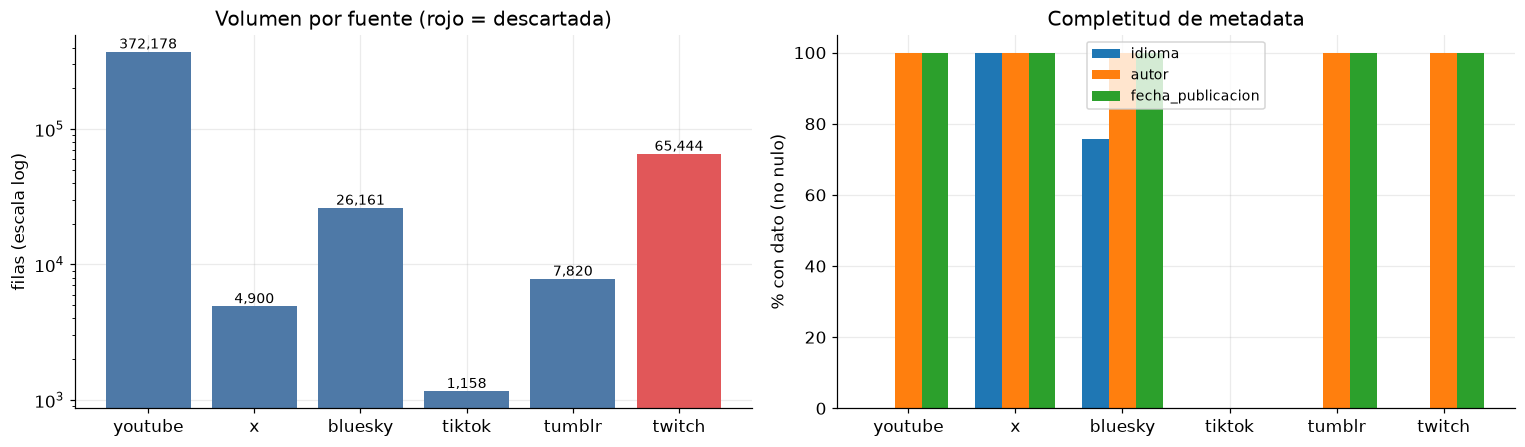

In [5]:
# Gráficos de la foto antes: volumen (log) y completitud de metadata por fuente.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.2))

orden = list(FUENTES)
colores = [ROJO if n in EXCLUIDAS else AZUL for n in orden]
ax1.bar(orden, [len(FUENTES[n]) for n in orden], color=colores)
ax1.set_yscale("log")
ax1.set_ylabel("filas (escala log)")
ax1.set_title("Volumen por fuente (rojo = descartada)")
for i, n in enumerate(orden):
    ax1.text(i, len(FUENTES[n]), f"{len(FUENTES[n]):,}", ha="center", va="bottom", fontsize=9)

campos = ["idioma", "autor", "fecha_publicacion"]
x = range(len(orden)); w = 0.25
for j, campo in enumerate(campos):
    completo = [100 * FUENTES[n][campo].notna().mean() for n in orden]
    ax2.bar([i + j * w for i in x], completo, w, label=campo)
ax2.set_xticks([i + w for i in x]); ax2.set_xticklabels(orden)
ax2.set_ylabel("% con dato (no nulo)"); ax2.set_ylim(0, 105)
ax2.set_title("Completitud de metadata"); ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 3. Diagnóstico de fuentes nuevas → qué entra y qué se descarta

Cuatro fuentes nuevas se evaluaron con el mismo léxico y criterios de calidad:

- **Bluesky (26k)** — metadata impecable, sin duplicados, **3.162 dirigida (12%)**.
  Reemplaza a la corrida vieja de 569. **Entra.**
- **Tumblr (7.8k)** — autor/fecha al 100%, **todo 2026**, textos reales multilingües.
  Poca señal dirigida pero suma una red nueva legítima. **Entra.**
- **TikTok (1.1k)** — a diferencia del intento viejo (off-topic, 2023-24), ahora
  **son comentarios reales del Mundial 2026**. Le falta autor/fecha (capturas de
  tarjetas), pero el texto es válido y el `idioma` se rellena con langdetect.
  **Entra con caveat** (metadata parcial).
- **Twitch (65k)** — se **descarta**; la evidencia está abajo.

Twitch es el chat de **un solo stream**: mensajes de mediana **11 caracteres**,
36% duplicados y **señal de xenofobia ≈ 0** (5 matches de léxico, todos falsos).
Meterlo diluiría el corpus con ruido sin aportar al análisis. Lo mostramos con
datos antes de excluirlo, para dejar constancia de la decisión.

In [5]:
tw = df_twitch
txt = tw["texto"].apply(normalizar_texto)
tl = txt.str.len()
print("=== Evidencia de por qué Twitch NO entra al corpus ===\n")
print(f"1) es el chat de UN SOLO stream: {tw['criterio_busqueda'].nunique()} criterio(s) de búsqueda")
print("   ", list(tw['criterio_busqueda'].unique())[:2])
print(f"\n2) mensajes ultra-cortos (chat, no comentarios):")
print(f"   mediana {int(tl.median())} chars | ≤5 chars: {100*(tl<=5).mean():.1f}% | ≤2 chars: {100*(tl<=2).mean():.1f}%")
print(f"\n3) altísima duplicación: {txt.duplicated().sum():,} de {len(tw):,} "
      f"({100*txt.duplicated().mean():.0f}%) son texto repetido")
disp = txt.apply(LEX.disparos)
hits = disp.apply(bool)
print(f"\n4) señal de xenofobia ≈ 0: solo {int(hits.sum())} filas tocan el léxico "
      f"(de {len(tw):,}), y son ruido:")
for t in txt[hits].head(6):
    print("   ·", t[:70])
print(f"\n5) muestra general (puro chat sin contenido analizable):")
for t in txt[tl > 2].sample(8, random_state=3):
    print("   ·", t[:70])
print("\n>>> DECISIÓN: Twitch se EXCLUYE del corpus consolidado.")
print(">>> TikTok, en cambio, SÍ se reincorpora: ahora son comentarios reales 2026 (metadata parcial).")

=== Evidencia de por qué Twitch NO entra al corpus ===

1) es el chat de UN SOLO stream: 1 criterio(s) de búsqueda
    ['ishowspeed: irl stream Portugal 🇵🇹 Vs Colombia 🇨🇴! Ronaldo Last Group Game⚽️World Cup Full Match Stream🌎!']

2) mensajes ultra-cortos (chat, no comentarios):
   mediana 11 chars | ≤5 chars: 22.7% | ≤2 chars: 0.0%

3) altísima duplicación: 23,744 de 65,444 (36%) son texto repetido



4) señal de xenofobia ≈ 0: solo 5 filas tocan el léxico (de 65,444), y son ruido:
   · Monos is a song
   · Banana 🍌
   · tas full box macaco
   · Simio
   · simio

5) muestra general (puro chat sin contenido analizable):
   · five guys
   · DUMBASS JAMAL
   · why do u even step on the KING??
   · poor hot dog
   · ISHOWFATMAC
   · in front of cops ?????
   · YOUR HOUSE BRO
   · world cup everybody jump

>>> DECISIÓN: Twitch se EXCLUYE del corpus consolidado.
>>> TikTok, en cambio, SÍ se reincorpora: ahora son comentarios reales 2026 (metadata parcial).


## 4. Reglas de curación 

Se aplican en orden a las **5 fuentes válidas** (YouTube, X, Bluesky, Tumblr, TikTok; Twitch quedó fuera). Cada paso reporta cuántas filas toca, para trazabilidad:

1. **Normalizar texto** — trim, colapsar espacios, unicode NFC.
2. **Descartar vacíos** — texto de ≤ 2 caracteres (no aporta señal).
3. **Anti-spam** — patrones de promo cripto/apuestas (el ruido típico del *amplia* de X).
4. **Dedup** — por `id` y por texto normalizado, **dentro de cada red**.
5. **Re-marcado con léxico v2** — `terminos`, `ejes`, `matchea_lexico`,
   corrigiendo los falsos positivos por substring (`monos`⊂*vámonos*, `simio`⊂*Simeone*).
6. **Columnas de calidad** — `es_dirigida`, `matchea_lexico`, `ejes`, `longitud`, `idioma` (rellenado).

In [6]:
MIN_CHARS = 2  # textos de 0..MIN_CHARS chars se descartan (vacíos / basura)

# Spam de promo cripto/apuestas: el patrón que ensucia el *amplia* de X.
# Conservador a propósito (evita descartar comentarios legítimos).
_SPAM = re.compile(
    r"(lbank|上線|上线|預測|预测|\bpredict\b|airdrop|\busdt\b|\bbnb\b|"
    r"claim.{0,15}(reward|token|airdrop)|\bt\.me/|join.{0,10}telegram|"
    r"\b\d+\s?x\b.{0,20}(上線|上线|listing|launch))",
    re.I,
)

#  Corrección de falsos positivos por substring (idéntica a los AED) 
_MONOS_FP = re.compile(
    r"\b(v[aá]monos|qued[eé]monos|imagin[eé]monos|ri[aá]monos|vay[aá]monos|"
    r"dig[aá]monos|hag[aá]monos|ve[aá]monos|pong[aá]monos|olvid[eé]monos|"
    r"sent[eé]monos|largu[eé]monos|call[eé]monos)\b", re.I)

def _es_fp(term, texto):
    t = str(texto).lower()
    if term == "monos":
        tiene_slur = bool(re.search(r"\bmonos?\b", t)) or "meximonos" in t
        return bool(_MONOS_FP.search(t)) and not tiene_slur
    if term == "simio":
        return ("simione" in t or "simeone" in t) and "simios" not in t and t.count("simio") <= 1
    return False

def curar(df_orig, nombre):
    """Aplica la cadena de curación a una fuente y reporta cada paso."""
    df = df_orig.copy()
    n0 = len(df)
    log = [("crudo", n0)]

    # 1) normalizar texto
    df["texto"] = df["texto"].apply(normalizar_texto)

    # 2) descartar vacíos / demasiado cortos
    df = df[df["texto"].str.len() > MIN_CHARS]
    log.append((f"tras quitar texto ≤{MIN_CHARS} chars", len(df)))

    # 3) anti-spam
    spam = df["texto"].apply(lambda t: bool(_SPAM.search(t)))
    if spam.any():
        df = df[~spam]
    log.append(("tras anti-spam", len(df)))

    # 4) dedup por id y por texto normalizado (dentro de la red)
    df = df.drop_duplicates(subset=["id"])
    log.append(("tras dedup por id", len(df)))
    df = df.drop_duplicates(subset=["texto"])
    log.append(("tras dedup por texto", len(df)))

    # 5) re-marcado con léxico compartido + corrección de FP
    disparos = df["texto"].apply(LEX.disparos)
    df["terminos"] = disparos.apply(lambda ds: [e.termino for e in ds])
    df["ejes"] = disparos.apply(lambda ds: sorted({e.eje for e in ds}))
    # matchea_lexico = tiene término real (descartando los que son puro FP)
    df["matchea_lexico"] = df.apply(
        lambda r: len(r["terminos"]) > 0 and not all(_es_fp(t, r["texto"]) for t in r["terminos"]),
        axis=1)
    # los FP puros no deben conservar términos/ejes fantasma
    solo_fp = df["terminos"].apply(bool) & ~df["matchea_lexico"]
    df.loc[solo_fp, ["terminos", "ejes"]] = df.loc[solo_fp, ["terminos", "ejes"]].map(lambda _: [])

    # 6) columnas de calidad
    df["es_dirigida"] = df["estrategia"] == "dirigida"
    df["longitud"] = df["texto"].str.len()

    print(f"{nombre}:")
    for etapa, n in log:
        print(f"   {etapa:32s}: {n:>7,}")
    print(f"   {'FINAL curado':32s}: {len(df):>7,}  (−{n0-len(df):,} = {100*(n0-len(df))/n0:.1f}%)")
    print(f"   matchea léxico (real): {int(df['matchea_lexico'].sum()):,} | dirigida: {int(df['es_dirigida'].sum()):,}\n")
    return df

curados = {n: curar(FUENTES[n], n) for n in FUENTES_VALIDAS}

youtube:
   crudo                           : 372,178
   tras quitar texto ≤2 chars      : 369,495
   tras anti-spam                  : 369,491
   tras dedup por id               : 369,491
   tras dedup por texto            : 357,064
   FINAL curado                    : 357,064  (−15,114 = 4.1%)
   matchea léxico (real): 742 | dirigida: 701

x:
   crudo                           :   4,900
   tras quitar texto ≤2 chars      :   4,900
   tras anti-spam                  :   4,896
   tras dedup por id               :   4,896
   tras dedup por texto            :   4,846
   FINAL curado                    :   4,846  (−54 = 1.1%)
   matchea léxico (real): 3,500 | dirigida: 4,739

bluesky:
   crudo                           :  26,161
   tras quitar texto ≤2 chars      :  26,161
   tras anti-spam                  :  26,122
   tras dedup por id               :  26,122
   tras dedup por texto            :  26,122
   FINAL curado                    :  26,122  (−39 = 0.1%)
   matchea léxico (real):

### 4b. Rellenar `idioma` faltante con `langdetect`

Varias fuentes no declaran idioma: YouTube (100% nulo), Tumblr y TikTok (100%),
y Bluesky tiene huecos (~24%). Detectar sobre las 357k filas de YouTube cuesta
~20 min, así que por defecto **en YouTube solo detectamos el núcleo denso**
(dirigida o con término del léxico) y en el resto de redes (chicas) detectamos
todos los nulos. Poné `DETECTAR_IDIOMA_TODO = True` para el pase completo (lento).

In [7]:
from langdetect import detect, DetectorFactory, LangDetectException
DetectorFactory.seed = 0

DETECTAR_IDIOMA_TODO = False  # True = detectar en TODO el corpus (~20 min sobre YouTube)

def _detectar(t):
    t = (t or "").strip()
    if len(t) < 12:            # muy corto → no fiable
        return None
    try:
        return detect(t)
    except LangDetectException:
        return None

for nombre, df in curados.items():
    # Si idioma viene 100% nulo, pandas la infiere float64 y no admite strings:
    # forzamos dtype object antes de asignar los idiomas detectados.
    df["idioma"] = df["idioma"].astype(object)
    falta = df["idioma"].isna()
    if not DETECTAR_IDIOMA_TODO and nombre == "youtube":
        # solo el núcleo relevante (dirigida o con léxico) para no tardar 20 min
        objetivo = falta & (df["es_dirigida"] | df["matchea_lexico"])
    else:
        objetivo = falta
    n = int(objetivo.sum())
    if n:
        df.loc[objetivo, "idioma"] = df.loc[objetivo, "texto"].apply(_detectar)
    print(f"{nombre:9s}: idioma detectado en {n:,} filas | idioma nulo restante: {df['idioma'].isna().sum():,}")

youtube  : idioma detectado en 832 filas | idioma nulo restante: 356,252
x        : idioma detectado en 0 filas | idioma nulo restante: 0
bluesky  : idioma detectado en 6,381 filas | idioma nulo restante: 0
tiktok   : idioma detectado en 1,158 filas | idioma nulo restante: 7
tumblr   : idioma detectado en 7,651 filas | idioma nulo restante: 248


## 5. Consolidación en 2 capas

- **`corpus_completo`** = todas las redes válidas curadas (YouTube + X + Bluesky
  + Tumblr + TikTok), con dedup global por `(red, id)`. Conserva toda la señal;
  P7 filtra con las columnas de calidad.
- **`corpus_dirigida`** = el subconjunto denso: recolección **dirigida** *o*
  **con término del léxico** en el texto. Es el núcleo auditable de xenofobia.

In [8]:
COLS_SALIDA = COLS + ["es_dirigida", "matchea_lexico", "ejes", "terminos", "longitud"]

completo = pd.concat([curados[n] for n in FUENTES_VALIDAS], ignore_index=True)
completo = completo.drop_duplicates(subset=["red", "id"]).reset_index(drop=True)
completo = completo[COLS_SALIDA]

dirigida = completo[completo["es_dirigida"] | completo["matchea_lexico"]].reset_index(drop=True)

print(f"corpus_completo: {len(completo):,} filas")
print("   por red:", completo["red"].value_counts().to_dict())
print(f"\ncorpus_dirigida: {len(dirigida):,} filas")
print("   por red:", dirigida["red"].value_counts().to_dict())
print("   por eje:", Counter(e for ejes in dirigida["ejes"] for e in ejes).most_common())

corpus_completo: 396,841 filas
   por red: {'youtube': 357064, 'bluesky': 26122, 'tumblr': 7651, 'x': 4846, 'tiktok': 1158}

corpus_dirigida: 8,783 filas
   por red: {'x': 4739, 'bluesky': 3161, 'youtube': 832, 'tumblr': 41, 'tiktok': 10}
   por eje: [('anti-negro / simiesco', 4765), ('sudamericano / regional', 1605), ('anti-mexicano / migrante', 893), ('colonial / autenticidad', 211), ('otros / genérico', 36), ('anti-asiático', 19)]


## 6. Foto después: comparativa antes → después

PERFIL DESPUÉS DE CURAR:


,filas,dirigida,matchea léxico,texto len (mediana),% idioma nulo,"dup (red,id)"
youtube,357064.0,701.0,742.0,62.0,99.8,0.0
x,4846.0,4739.0,3500.0,153.0,0.0,0.0
bluesky,26122.0,3161.0,3161.0,156.0,0.0,0.0
tiktok,1158.0,10.0,10.0,46.0,0.6,0.0
tumblr,7651.0,41.0,11.0,78.0,3.2,0.0
CONSOLIDADO,396841.0,8652.0,7424.0,66.0,89.8,0.0


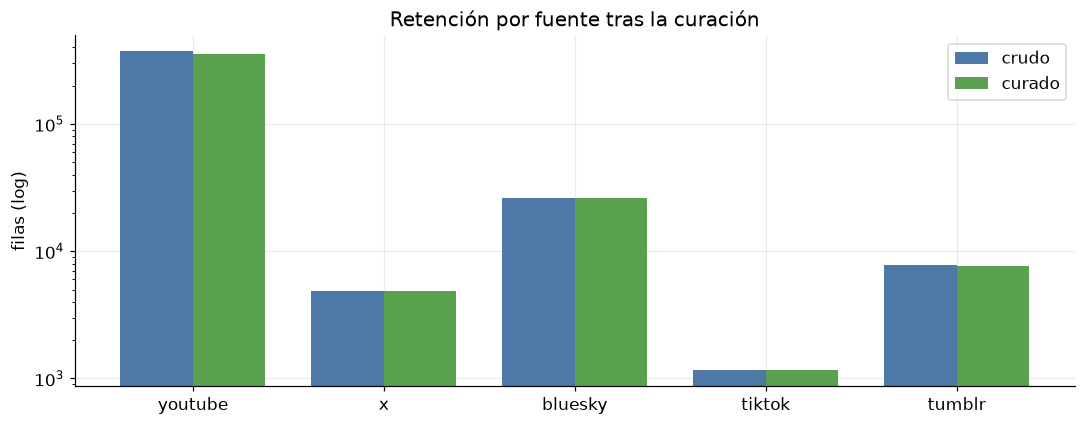

In [9]:
def perfilar_curado(df, nombre):
    return {
        "filas": len(df),
        "dirigida": int(df["es_dirigida"].sum()),
        "matchea léxico": int(df["matchea_lexico"].sum()),
        "texto len (mediana)": int(df["longitud"].median()) if len(df) else 0,
        "% idioma nulo": round(100 * df["idioma"].isna().mean(), 1),
        "dup (red,id)": int(df.duplicated(subset=["red", "id"]).sum()),
    }

perfil_despues = pd.DataFrame({n: perfilar_curado(curados[n], n) for n in curados} |
                              {"CONSOLIDADO": perfilar_curado(completo, "todo")}).T
print("PERFIL DESPUÉS DE CURAR:")
display(perfil_despues)

# Antes vs después (filas retenidas por fuente)
fig, ax = plt.subplots(figsize=(10, 4))
orden = list(curados)
antes = [perfil_antes.loc[n, "filas"] for n in orden]
despues = [len(curados[n]) for n in orden]
x = range(len(orden)); w = 0.38
ax.bar([i - w/2 for i in x], antes, w, label="crudo", color=AZUL)
ax.bar([i + w/2 for i in x], despues, w, label="curado", color=VERDE)
ax.set_yscale("log"); ax.set_xticks(list(x)); ax.set_xticklabels(orden)
ax.set_ylabel("filas (log)"); ax.set_title("Retención por fuente tras la curación")
ax.legend(); plt.tight_layout(); plt.show()

## 7. Exportar el corpus curado + reporte

`metricas` se serializa como JSON string en CSV (contrato) y como objeto anidado
en JSONL. Las listas `ejes`/`terminos` van como JSON en ambos.

In [10]:
def exportar(df, base):
    """Escribe <base>.csv y <base>.jsonl en DATA_OUT."""
    out = df.copy()
    # CSV: dicts/listas → JSON string
    csv_df = out.copy()
    for c in ["metricas", "ejes", "terminos"]:
        csv_df[c] = csv_df[c].apply(lambda v: json.dumps(v, ensure_ascii=False))
    csv_df.to_csv(DATA_OUT / f"{base}.csv", index=False)
    # JSONL: objetos anidados
    with open(DATA_OUT / f"{base}.jsonl", "w", encoding="utf-8") as f:
        for rec in out.to_dict(orient="records"):
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
    print(f"  {base}.csv / .jsonl  → {len(df):,} filas")

print("Exportando a", DATA_OUT)
exportar(completo, "corpus_completo")
exportar(dirigida, "corpus_dirigida")

Exportando a /home/felipep/Documentos/universidad/universidad 8vo/computacion_paralela/proyecto_final_ciclo/practica_07/data
  corpus_completo.csv / .jsonl  → 396,841 filas
  corpus_dirigida.csv / .jsonl  → 8,783 filas


In [11]:
# Reporte de curación en Markdown (para el informe / la rúbrica).
ahora = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")
_tw_txt = df_twitch["texto"].apply(normalizar_texto)
lineas = [
    "# Reporte de curación de datos", "",
    f"Generado: {ahora}", "",
    "## Fuentes de entrada (crudo)", "",
    perfil_antes[["filas", "dirigida", "amplia", "dup texto", "% idioma nulo", "% autor nulo"]].to_markdown(),
    "", "## Decisiones sobre fuentes nuevas", "",
    "- **Bluesky (26k)** — *incluido*. Reemplaza la corrida vieja de 569; metadata "
    f"completa, {int((df_bluesky['estrategia']=='dirigida').sum()):,} filas dirigida.",
    "- **Tumblr (7.8k)** — *incluido*. Autor/fecha al 100%, todo 2026, textos reales "
    "multilingües; nueva red legítima.",
    "- **TikTok (1.1k)** — *incluido con caveat*. A diferencia del intento previo "
    "(off-topic, 2023-24) ahora son comentarios reales del Mundial 2026; le falta "
    "autor/fecha (capturas de tarjetas) pero el texto es válido y el idioma se rellena.",
    f"- **Twitch ({len(df_twitch):,})** — **EXCLUIDO.** Chat de un solo stream "
    f"({df_twitch['criterio_busqueda'].nunique()} criterio): mensajes de mediana "
    f"{int(_tw_txt.str.len().median())} chars, {100*_tw_txt.duplicated().mean():.0f}% duplicados "
    "y señal de xenofobia ≈ 0 (matches de léxico todos falsos). Diluiría el corpus con ruido.",
    "", "## Corpus resultante (curado)", "",
    perfil_despues.to_markdown(), "",
    "## Salidas", "",
    f"- `corpus_completo` — {len(completo):,} filas | por red: {completo['red'].value_counts().to_dict()}",
    f"- `corpus_dirigida` — {len(dirigida):,} filas | por red: {dirigida['red'].value_counts().to_dict()}",
    f"  - por eje del odio: {dict(Counter(e for ejes in dirigida['ejes'] for e in ejes).most_common())}",
    "", "## Reglas aplicadas", "",
    "1. Normalización de texto (trim, espacios, unicode NFC).",
    f"2. Descarte de texto ≤ {MIN_CHARS} caracteres.",
    "3. Anti-spam (promo cripto/apuestas).",
    "4. Dedup por `id` y por texto normalizado, dentro de cada red.",
    "5. Re-marcado con léxico v2 compartido + corrección de falsos positivos "
    "(`monos`⊂vámonos, `simio`⊂Simeone).",
    "6. Relleno de `idioma` con langdetect en el núcleo denso.",
]
(DATA_OUT / "reporte_curacion.md").write_text("\n".join(lineas), encoding="utf-8")
print((DATA_OUT / "reporte_curacion.md").read_text(encoding="utf-8"))

# Reporte de curación de datos

Generado: 2026-07-15 13:40 UTC

## Fuentes de entrada (crudo)

|         |   filas |   dirigida |   amplia |   dup texto |   % idioma nulo |   % autor nulo |
|:--------|--------:|-----------:|---------:|------------:|----------------:|---------------:|
| youtube |  372178 |        715 |   371463 |       14627 |           100   |              0 |
| x       |    4900 |       4781 |      119 |          50 |             0   |              0 |
| bluesky |   26161 |       3162 |    22999 |           0 |            24.4 |              0 |
| tiktok  |    1158 |         10 |     1148 |           0 |           100   |            100 |
| tumblr  |    7820 |         41 |     7779 |         146 |           100   |              0 |
| twitch  |   65444 |          0 |    65444 |       23744 |           100   |              0 |

## Decisiones sobre fuentes nuevas

- **Bluesky (26k)** — *incluido*. Reemplaza la corrida vieja de 569; metadata completa, 3,162 filas dirigida